## Simulating any compartmental model using the `Spp` class with time-dependent parameters

In the present notebook, we show how (most) compartmenal models can be simulated using the `pyross.deterministic.Spp` class. In addition to the standard functionality of `Spp`, we show here how an arbitrary time-dependence of parameters can be specified

In [1]:
%matplotlib inline
import numpy as np
import pyross
import matplotlib.pyplot as plt
#from matplotlib import rc; rc('text', usetex=True)

### The SIR model

Below you will find the model-specification dictionary for the SIR model with some constant injection into the I class (corresponding to the immigration of infecteds):

In [2]:
model_spec = {
    "classes" : ["S", "I"],

    "S" : { 
        "infection" : [ ["I", "-beta"] ]
    },

    "I" : {
        "constant"  : [ ["k"] ],
        "linear"    : [ ["I", "-gamma"] ],
        "infection" : [ ["I", "beta"] ]
    }
}

This corresponds to

$$
\begin{aligned}
\dot{S}_i & =  - \beta \sum_j C_{ij} \frac{I_j}{N_j} S_i \\
\dot{I}_i & = k(t) + \beta \sum_j C_{ij} \frac{I_j}{N_j} S_i - \gamma I_i \\
\dot{R}_i & = \gamma I_i
\end{aligned}
$$

See example 16 for the syntax of `Spp`.

Next, we define the parameter values:

In [3]:
parameters = {
    'beta' : 0.1,
    'gamma' : 0.1, 
    'ki' : 10, 
    'kf' : 0, 
}

We want to specify that after day 20, borders are closed, so the parameter $k(t)$ drops from `ki` to zero. For this purpose, we specify a time dependent mapping of above parameters to the parameters of the model.

In [4]:
def parameter_mapping(input_parameters, t):
    output_parameters = {
        'beta' : input_parameters['beta'] ,
        'gamma' : input_parameters['gamma'] 
    }
    if t<20:
        output_parameters['k'] = input_parameters['ki']
    else:
        output_parameters['k'] = input_parameters['kf']
    return output_parameters

In [5]:
M = 3                
Ni = 1000*np.ones(M)
N = np.sum(Ni) 


# Initial conditions as an array
x0 = np.array([
    999, 1000, 1000, # S
    1,   0,    0,    # I
])

# Or initial conditions as a dictionary 
I0 = [10, 10, 10]
S0 = [n-20 for n in Ni]

x0 = {
    'S' : S0,
    'I' : I0 
}

CM = np.array([
    [1,   0.5, 0.1],
    [0.5, 1,   0.5],
    [0.1, 0.5, 1  ]
], dtype=float)

def contactMatrix(t):  
    return CM

# duration of simulation and data file
Tf = 160;  Nf=Tf+1; 

model = pyross.deterministic.Spp(model_spec, parameters, M, Ni, time_dep_param_mapping=parameter_mapping)
# simulate model 

In [7]:
%timeit pyross.deterministic.Spp(model_spec, parameters, M, Ni, time_dep_param_mapping=parameter_mapping)


185 μs ± 9.87 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [8]:
%timeit model.simulate(x0, contactMatrix, Tf, Nf)

31.2 ms ± 1.64 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
data = model.simulate(x0, contactMatrix, Tf, Nf)

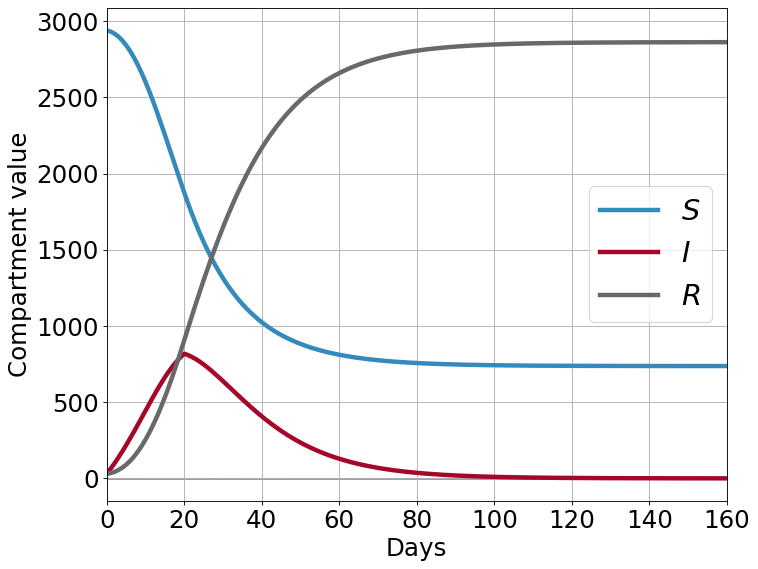

In [6]:
# plot the data and obtain the epidemic curve
S = np.sum(model.model_class_data('S', data), axis=1)
I = np.sum(model.model_class_data('I', data), axis=1)
R = np.sum(model.model_class_data('R', data), axis=1)
t = data['t']

fig = plt.figure(num=None, figsize=(10, 8), dpi=80, facecolor='w', edgecolor='k')
plt.rcParams.update({'font.size': 22})

plt.fill_between(t, 0, S/N, color="#348ABD", alpha=0.3)
plt.plot(t, S, '-', color="#348ABD", label='$S$', lw=4)

plt.fill_between(t, 0, I/N, color='#A60628', alpha=0.3)
plt.plot(t, I, '-', color='#A60628', label='$I$', lw=4)

plt.fill_between(t, 0, R/N, color="dimgrey", alpha=0.3)
plt.plot(t, R, '-', color="dimgrey", label='$R$', lw=4)

plt.legend(fontsize=26); plt.grid() 
plt.autoscale(enable=True, axis='x', tight=True)
plt.ylabel('Compartment value')
plt.xlabel('Days');

We can use `pyross.deterministic.Spp.update_model_parameters` to change the parameters from what we set them initially (for example to see what would have happened had the borders been closed from the beginning):

In [7]:
parameters = {
    'beta' : 0.1,
    'gamma' : 0.1,
    'ki': 0,
    'kf': 0
    
}

model.update_model_parameters(parameters)

# simulate model 
data = model.simulate(x0, contactMatrix, Tf, Nf)

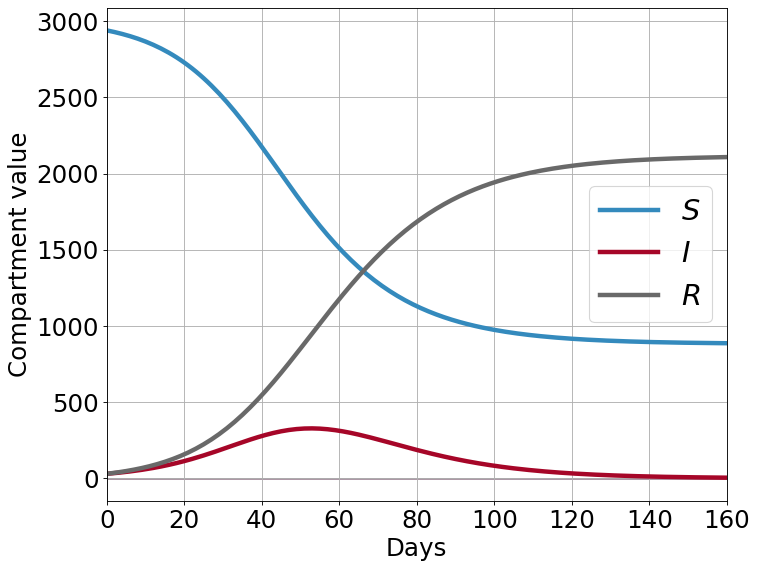

In [8]:
# plot the data and obtain the epidemic curve
S = np.sum(model.model_class_data('S', data), axis=1)
I = np.sum(model.model_class_data('I', data), axis=1)
R = np.sum(model.model_class_data('R', data), axis=1)
t = data['t']

fig = plt.figure(num=None, figsize=(10, 8), dpi=80, facecolor='w', edgecolor='k')
plt.rcParams.update({'font.size': 22})

plt.fill_between(t, 0, S/N, color="#348ABD", alpha=0.3)
plt.plot(t, S, '-', color="#348ABD", label='$S$', lw=4)

plt.fill_between(t, 0, I/N, color='#A60628', alpha=0.3)
plt.plot(t, I, '-', color='#A60628', label='$I$', lw=4)

plt.fill_between(t, 0, R/N, color="dimgrey", alpha=0.3)
plt.plot(t, R, '-', color="dimgrey", label='$R$', lw=4)

plt.legend(fontsize=26); plt.grid() 
plt.autoscale(enable=True, axis='x', tight=True)
plt.ylabel('Compartment value')
plt.xlabel('Days');

In [9]:
data

{'X': array([[ 980.        ,  980.        ,  980.        , ..., 1000.        ,
         1000.        , 1000.        ],
        [ 978.37790346,  977.9656034 ,  978.37790346, ..., 1000.        ,
         1000.        , 1000.        ],
        [ 976.64263582,  975.77632706,  976.64263582, ..., 1000.        ,
         1000.        , 1000.        ],
        ...,
        [ 324.55022788,  238.35996094,  324.55022788, ..., 1000.        ,
         1000.        , 1000.        ],
        [ 324.4646717 ,  238.28279219,  324.4646717 , ..., 1000.        ,
         1000.        , 1000.        ],
        [ 324.3832828 ,  238.20939197,  324.3832828 , ..., 1000.        ,
         1000.        , 1000.        ]]),
 't': array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
         11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
         22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
         33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  

In [10]:
model.model_class_data('S', data)

array([[980.        , 980.        , 980.        ],
       [978.37790346, 977.9656034 , 978.37790346],
       [976.64263582, 975.77632706, 976.64263582],
       [974.78646068, 973.42269823, 974.78646068],
       [972.80128641, 970.8947984 , 972.80128641],
       [970.67866807, 968.18227448, 970.67866807],
       [968.40981434, 965.27435704, 968.40981434],
       [965.98559929, 962.15988593, 965.98559929],
       [963.39657925, 958.82734257, 963.39657925],
       [960.63301614, 955.26489198, 960.63301614],
       [957.68490769, 951.46043422, 957.68490769],
       [954.54202434, 947.40166517, 954.54202434],
       [951.19395596, 943.07615079, 951.19395596],
       [947.63016736, 938.47141325, 947.63016736],
       [943.84006196, 933.57502788, 943.84006196],
       [939.81305682, 928.3747351 , 939.81305682],
       [935.53866851, 922.85856618, 935.53866851],
       [931.00660922, 917.01498196, 931.00660922],
       [926.20689398, 910.83302487, 926.20689398],
       [921.12995851, 904.30248

In [12]:
data['X'].shape

(161, 9)

In [ ]:
data_ = data.copy()

In [ ]:
data_['X']/=2

In [ ]:
model.model_class_data('S', data)

In [17]:
data['X'][:10,:].T

array([[ 980.        ,  978.37790346,  976.64263582,  974.78646068,
         972.80128641,  970.67866807,  968.40981434,  965.98559929,
         963.39657925,  960.63301614],
       [ 980.        ,  977.9656034 ,  975.77632706,  973.42269823,
         970.8947984 ,  968.18227448,  965.27435704,  962.15988593,
         958.82734257,  955.26489198],
       [ 980.        ,  978.37790346,  976.64263582,  974.78646068,
         972.80128641,  970.67866807,  968.40981434,  965.98559929,
         963.39657925,  960.63301614],
       [  10.        ,   10.59287051,   11.2370787 ,   11.93510375,
          12.68952741,   13.50302187,   14.37833461,   15.31826978,
          16.32566706,   17.40337583],
       [  10.        ,   10.98554994,   12.02477368,   13.12158105,
          14.27993458,   15.50383305,   16.79729072,   18.16431139,
          19.60885867,   21.13481975],
       [  10.        ,   10.59287051,   11.2370787 ,   11.93510375,
          12.68952741,   13.50302187,   14.37833461,   15